## Exercise 1 - optimizing multiple parameters

In this exercise you'll generalize the terrain navigation problem to multiple terrains by jointly optimizing over several parameters.

<img src="artifacts/ex1/problem.png" style="margin: 0 auto; width: 42em;" />

### Imports and constants

In [1]:
import torch
from utils.ex1 import *

In [2]:
V1 = .7   # Speed on first terrain
V2 = .3   # Speed on second terrain
V3 = .45  # Speed on third terrain
H = 20
D = 10

### Time computation

Implement a function that accepts $ x_1 $ and $ x_2 $, and returns the time to traverse the path. Remember to use `torch` operations so that the computation can be differentiated automatically.

$$ time(x_1, x_2) = \frac{\sqrt{x_1^2 + D^2}}{V_1} + \frac{\sqrt{x_2^2 + D^2}}{V_2} + \frac{\sqrt{(H - x_1 - x_2)^2 + D^2}}{V_3} $$

In [3]:
def calculate_time(x1, x2):
    x3 = H - x1 - x2
    return torch.sqrt(x1 ** 2 + D ** 2) / V1 + torch.sqrt(x2 ** 2 + D ** 2) / V2 + torch.sqrt(x3 ** 2 + D ** 2) / V3

### Gradient descent
Implement gradient descent to find a path that minimizes the time to traverse the path.

Use the following helper functions to get a visualization of the optimization:
1. `reset_history()` before the optimization
2. `log_history(time, params)` in every iteration. `time` is the computed time you're minimizing; `params` is a tuple of $ x_1 $ and $ x_2 $.
3. `visualize_history()` after the optimization

You should be able to reduce the traversal time to a little over 80 seconds.

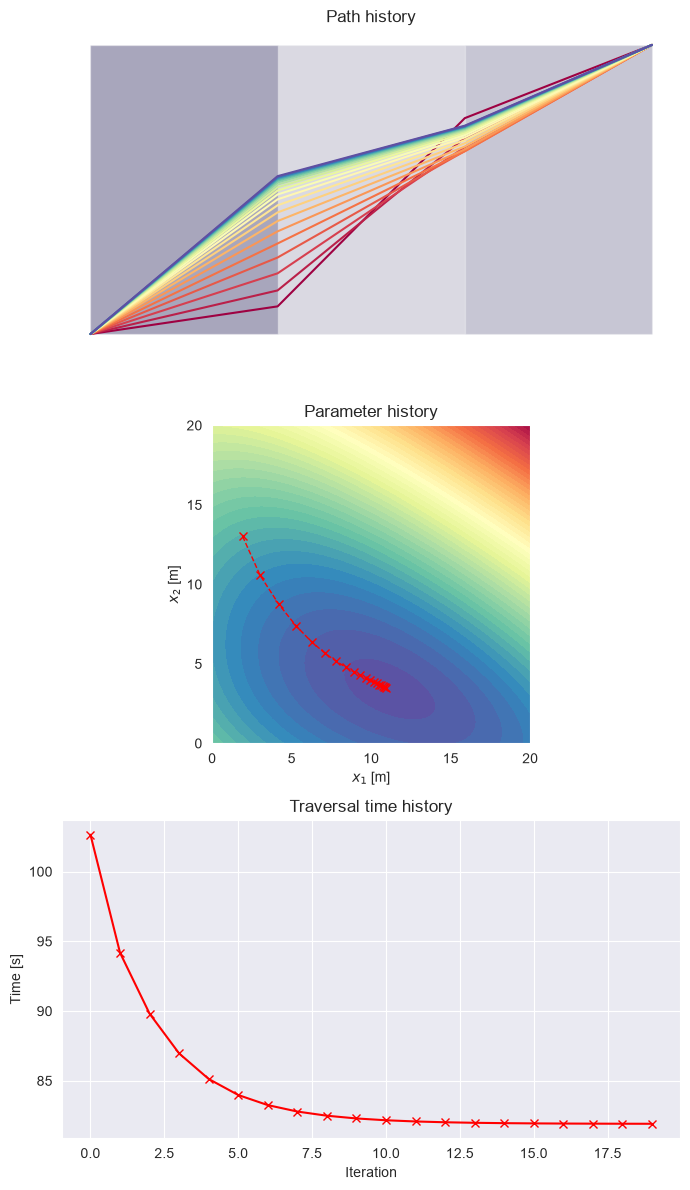

In [4]:
reset_history()

x1 = torch.tensor(.1 * H, requires_grad=True)
x2 = torch.tensor(.85 * H, requires_grad=True)
optimizer = torch.optim.SGD([x1, x2], lr=1.5)
for i in range(20):
    time = calculate_time(x1, x2)
    
    optimizer.zero_grad()
    time.backward()
    optimizer.step()

    log_history(time, (x1, x2))

visualize_history()

### Food for thought

1. How does initialization affect the result?
2. How does the step size affect the optimization? What happens when it's too large? Or too small?